In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import scanpy as sc
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
import pickle

In [8]:
# this part with adata_sc doesnt really matter, this is just to remove that extra one merfish gene (from 315 to 314)
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
keep_cells = adata_mer.obs['leiden']!='5'
adata_mer = adata_mer[keep_cells,:]


import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
all_spatial= adata_mer.obsm['spatial']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    

### adding nicheformers

In [9]:
# load nicheformer results 
fileloc = '/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/adata_mer_embedded_2025-05-27.h5ad'
adata_niche = sc.read_h5ad(fileloc)

In [10]:
adata_niche
X_niche = adata_niche.obsm['nicheformer'][keep_cells]
X_niche.shape

(2252, 512)

In [11]:
adata_foo.shape, adata_mer.shape, X_niche.shape

((4895, 5126), (2252, 314), (2252, 512))

In [12]:
X_niche.max(),X_niche.min()

(np.float32(2.2737803), np.float32(-5.340035))

# processs
1. normalized X 
2. scale coords

## 1. scale X

In [14]:
X = adata_mer.X.A if hasattr(adata_mer.X, "A") else adata_mer.X  # handle sparse
scaler = StandardScaler().fit(X)
X = scaler.transform(X)
scaler = StandardScaler().fit(X_niche)
X_niche = scaler.transform(X_niche)


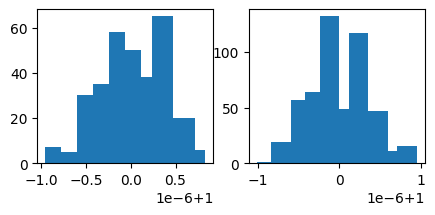

In [17]:
plt.figure(figsize = (5,2))
plt.subplot(1,2,1)
plt.hist(np.std(X,0), bins = 10);
plt.subplot(1,2,2)
plt.hist(np.std(X_niche,0), bins = 10);

## 2. scale Y 

In [18]:
coords = all_spatial.copy()
coords -= np.min(coords, 0)
coords /= coords.max()

In [19]:
np.min(coords,0), np.max(coords,0)

(array([0., 0., 0.]), array([0.31120343, 1.        , 0.58273186]))

## 3. train test split

In [20]:

X_train, X_tmp, X_niche_train, X_niche_tmp, y_train, y_tmp = train_test_split(
    X, X_niche, coords, 
    test_size=0.40,
    random_state=42)

X_val, X_test, X_niche_val, X_niche_test, y_val, y_test = train_test_split(
    X_tmp, X_niche_tmp, y_tmp, 
    test_size=0.50,
    random_state=42)


In [21]:
X_train.shape, X_niche_train.shape

((1351, 314), (1351, 512))

In [23]:
X_val.shape, X_niche_val.shape

((450, 314), (450, 512))

In [1]:
alldata = dict()
alldata['X_train']=X_train
alldata['X_test']=X_test
alldata['X_val']=X_val

alldata['X_niche_train']=X_niche_train
alldata['X_niche_test']=X_niche_test
alldata['X_niche_val']=X_niche_val

alldata['y_train']=y_train
alldata['y_test']=y_test
alldata['y_val']=y_val


filename = '/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/gene_to_loc_predict/data/data_loc_to_gene.pkl'
pickle.dump(alldata, open(filename,'wb'))

NameError: name 'X_train' is not defined